# Urgency Prediction — ML Pipeline

**Decision Intelligence Assistant · Week 3 Bootcamp**

This notebook builds the trained ML baseline for ticket-priority prediction. It is the `ml-classifier` half of the four-way comparison (RAG / non-RAG / ML / LLM zero-shot). Outputs are persisted to `../models/` and `../dataset/processed/` for consumption by the FastAPI backend and the RAG pipeline downstream.

### Phases
0. Setup & Data Import
1. Integrity & Cleaning
2. EDA
3. Labeling Function (Weak Supervision) — scored rule, threshold calibrated to 15-20% positive
3.8 Stratified down-sample to 300k for training tractability
4. Train / Val / Test Split
5. Feature Engineering (row-independent features precomputed)
6. Feature Analysis
7. Model Training (sklearn Pipeline + ColumnTransformer, leakage-safe)
8. Evaluation (metrics, calibration, latency) + optional full-data confirmation
9. Honesty Check & Artifact Persistence

### Problem framing
- **Input at inference:** raw customer message text only. No thread context, no brand metadata, no timestamp.
- **Output:** `{0: normal, 1: urgent}` + calibrated probability.
- **Target operating point:** recall on urgent ≥ 0.75 at precision ≥ 0.60.
- **Latency budget:** ≤ 10 ms/prediction on CPU.

### Leakage discipline (explicit contract)
A feature is leakage-free iff its value for row A does not depend on any other row. We split features into two groups:

| Type | Example | Treatment |
|---|---|---|
| Row-independent | VADER scores, char_len, caps_ratio, keyword flags | Precompute once on the full dataframe |
| Row-dependent | TF-IDF IDF weights, StandardScaler mean/std | Kept inside the sklearn Pipeline; fit on train only |

This keeps the Pipeline's leakage barrier airtight while letting us precompute expensive-but-safe features up front.

## Phase 0 — Setup & Data Import

### 0.1 Imports

In [2]:
# --- Standard library ---
import os, re, json, time, pickle, warnings, random
from pathlib import Path
from collections import Counter

# --- Data ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- NLP ---
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# --- ML: preprocessing / pipelines ---
from scipy.sparse import hstack, csr_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

# --- ML: models ---
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('LightGBM not available — will skip that model. Install with: pip install lightgbm')

# --- ML: calibration & metrics ---
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

# --- Persistence ---
import joblib

# --- Config ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Download NLTK assets once (harmless if already present)
for pkg in ['punkt', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{pkg}' if pkg == 'punkt' else f'corpora/{pkg}')
    except LookupError:
        nltk.download(pkg, quiet=True)

print('Imports OK')

Imports OK


### 0.2 Paths

In [3]:
DATA_DIR       = Path('../dataset')
RAW_PATH       = DATA_DIR / 'twcs.csv'
PROCESSED_DIR  = DATA_DIR / 'processed'
ARTIFACTS_DIR  = Path('../models')
REPORTS_DIR    = Path('../reports')  # plots, adversarial set, etc.

for d in [PROCESSED_DIR, ARTIFACTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Development switch ---
# Set to an int (e.g. 100_000) while iterating; set to None for full 3M-row runs.
DEV_SAMPLE_SIZE = None

print(f'Paths ready. DEV_SAMPLE_SIZE = {DEV_SAMPLE_SIZE}')

Paths ready. DEV_SAMPLE_SIZE = None


### 0.3 Load the raw dataset

Load `twcs.csv` as UTF-8 and cache it as parquet for 20× faster subsequent loads. Parquet preserves dtypes and avoids re-mangling encoding on re-read.

If sampled rows show apostrophes as `â€™` or emojis as `ðŸ`, the encoding is wrong — **do not proceed**. Fix the encoding first.

In [4]:
RAW_PARQUET = PROCESSED_DIR / 'twcs_raw.parquet'

if RAW_PARQUET.exists():
    df_raw = pd.read_parquet(RAW_PARQUET)
    print(f'Loaded cached parquet: {len(df_raw):,} rows')
else:
    df_raw = pd.read_csv(RAW_PATH, encoding='utf-8', low_memory=False)
    df_raw.to_parquet(RAW_PARQUET, index=False)
    print(f'Loaded and cached: {len(df_raw):,} rows')

if DEV_SAMPLE_SIZE is not None:
    df_raw = df_raw.sample(n=DEV_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'DEV MODE: sampled down to {len(df_raw):,} rows')

df_raw.head(3)

Loaded cached parquet: 2,811,774 rows


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0


In [5]:
# Encoding sanity check — should show normal apostrophes/emojis
for t in df_raw['text'].dropna().sample(5, random_state=1).tolist():
    print('-', t)

- @ATVIAssist pls fix HQs !!
- @AppleSupport iPhone 6S with 11.0.2 iOS
- Either I'm dumb bc I don't know how to use the App Store or @AmericanAir is bc I think they don't have an iOS app. #DigitalTransformation
- @502234 @115858 It’s such a pain mine is doing it too
- @677157 Sorry we got it wrong! Could you send us a DM with more info so we can sort it out for you? ^KR


## Phase 1 — Integrity & Cleaning

Goal: produce `inbound_clean.parquet`, a dataframe of customer messages with obvious junk removed. No plots yet — those belong in Phase 2.

### Filters applied
1. `inbound == False` → company replies are not tickets. Drop.
2. Null text → drop.
3. Text length < 5 chars (`'k'`, `'.'`, `'ok'`) → drop.
4. Exact duplicate text → keep first. (Cross-brand duplicates don't occur because `@brand` is in the text string — verified empirically.)

**No filtering on thread position.** Late-turn messages carry the escalation signal we want to learn.

### 1.1 Schema and null check

In [6]:
print('Shape:', df_raw.shape)
print('\nDtypes:\n', df_raw.dtypes)
print('\nNull counts:\n', df_raw.isna().sum())
print('\nInbound distribution:\n', df_raw['inbound'].value_counts())

Shape: (2811774, 7)

Dtypes:
 tweet_id                     int64
author_id                      str
inbound                       bool
created_at                     str
text                           str
response_tweet_id              str
in_response_to_tweet_id    float64
dtype: object

Null counts:
 tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

Inbound distribution:
 inbound
True     1537843
False    1273931
Name: count, dtype: int64


### 1.2 Parse datetime and reply-id columns

`response_tweet_id` is comma-separated in some rows (a tweet can have multiple direct replies — e.g. `'9,6,10'`). We parse it into a list-of-ints column for Phase 2 analysis; not needed for the production model.

In [7]:
def parse_response_ids(val):
    if pd.isna(val):
        return []
    return [int(x.strip()) for x in str(val).split(',') if x.strip().lstrip('-').isdigit()]

df_raw['created_at'] = pd.to_datetime(
    df_raw['created_at'], format='%a %b %d %H:%M:%S %z %Y', errors='coerce'
)
df_raw['response_ids'] = df_raw['response_tweet_id'].apply(parse_response_ids)
df_raw['in_response_to_tweet_id'] = pd.to_numeric(
    df_raw['in_response_to_tweet_id'], errors='coerce'
).astype('Int64')

print('Datetime parse failures:', df_raw['created_at'].isna().sum())
print('Multi-reply rows:', (df_raw['response_ids'].str.len() > 1).sum())

Datetime parse failures: 0
Multi-reply rows: 222426


### 1.3 Apply cleaning filters

Each filter logs *what* gets dropped, not just the count. If a reviewer later asks 'what did you throw away?' the answer is in the notebook output.

**Note on duplicate drops:** verified empirically that duplicated texts do not span multiple brands (because the `@brand` mention is part of the text string). The rows dropped here are short acknowledgments (`Yes`, `Thanks`, `Done`) and placeholder text (`__email__`), not semantic duplicates across different support contexts.

In [8]:
n0 = len(df_raw)

# 1. Inbound only
df = df_raw[df_raw['inbound'] == True].copy()
n1 = len(df)
print(f'After inbound filter: {n1:,}  (dropped {n0-n1:,} outbound)')

# 2. Drop null texts
df = df.dropna(subset=['text'])
n2 = len(df)
print(f'After null-text drop: {n2:,}  (dropped {n1-n2:,})')

# 3. Drop very short texts
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() >= 5]
n3 = len(df)
print(f'After <5-char drop: {n3:,}  (dropped {n2-n3:,})')

# 4. Audit what dedup removes before dropping
dropped_examples = df[df.duplicated(subset=['text'], keep='first')]['text'].value_counts().head(10)
print('\nTop 10 duplicate texts about to be dropped (audit log):')
for t, c in dropped_examples.items():
    print(f'  [{c}x]  {t[:140]}')

df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
n4 = len(df)
print(f'\nAfter dedup: {n4:,}  (dropped {n3-n4:,})')
print(f'Final inbound-clean: {n4:,} rows ({n4/n0*100:.1f}% of raw)')

After inbound filter: 1,537,843  (dropped 1,273,931 outbound)
After null-text drop: 1,537,843  (dropped 0)
After <5-char drop: 1,537,790  (dropped 53)

Top 10 duplicate texts about to be dropped (audit log):
  [286x]  @AirAsiaSupport
  [278x]  @Uber_Support __email__
  [178x]  @VerizonSupport Yes
  [173x]  @AppleSupport 11.0.3
  [167x]  @HPSupport [TYPE YOUR QUESTION HERE] #hppsdr #ijkhelp
  [166x]  @azuresupport #azTechHelp
  [160x]  @AmazonHelp Yes
  [160x]  @ComcastCares
#mobile_Care
  [139x]  @Uber_Support Done
  [131x]  @AmazonHelp Done

After dedup: 1,511,751  (dropped 26,039)
Final inbound-clean: 1,511,751 rows (53.8% of raw)


### 1.4 Recover mentioned brand (for stratification only)

The `@brand` mention is a reliable proxy for which company the customer is tweeting at. **Used only for stratified splitting in Phase 4, never as a model feature** (the production UI has no brand metadata).

In [9]:
BRAND_PATTERN = re.compile(r'@(\w+)')

def extract_mentioned_brand(text):
    m = BRAND_PATTERN.search(text)
    return m.group(1).lower() if m else 'unknown'

df['brand'] = df['text'].apply(extract_mentioned_brand)
top_brands = df['brand'].value_counts().head(10).index.tolist()
df['brand_bucket'] = df['brand'].where(df['brand'].isin(top_brands), 'other')

print('Top brand buckets:')
print(df['brand_bucket'].value_counts())

Top brand buckets:
brand_bucket
other           996046
amazonhelp      123531
applesupport     83508
unknown          55821
americanair      44987
delta            40496
uber_support     40056
virgintrains     32924
115858           32660
southwestair     32288
tesco            29434
Name: count, dtype: int64


### 1.5 Drop the now-constant `inbound` column and persist

In [10]:
df = df.drop(columns=['inbound'])  # constant = True after filter

CLEAN_PARQUET = PROCESSED_DIR / 'inbound_clean.parquet'
df.to_parquet(CLEAN_PARQUET, index=False)
print(f'Saved {len(df):,} rows -> {CLEAN_PARQUET}')
df.head(3)

Saved 1,511,751 rows -> ..\dataset\processed\inbound_clean.parquet


,tweet_id,author_id,created_at,text,response_tweet_id,in_response_to_tweet_id,response_ids,brand,brand_bucket
0,2,115712,2017-10-31 22:11:45+00:00,@sprintcare and how do you propose we do that,NaN,1,[],sprintcare,other
1,3,115712,2017-10-31 22:08:27+00:00,@sprintcare I have sent several private messages and no one is responding as usual,1,4,[1],sprintcare,other
2,5,115712,2017-10-31 21:49:35+00:00,@sprintcare I did.,4,6,[4],sprintcare,other


## Phase 2 — Exploratory Data Analysis

Now that data is clean, look at it. The goal is **to shape the labeling function in Phase 3**, not to generate pretty plots. Every chart in this section should answer a specific question that affects a downstream decision.

### 2.1 Text length distributions

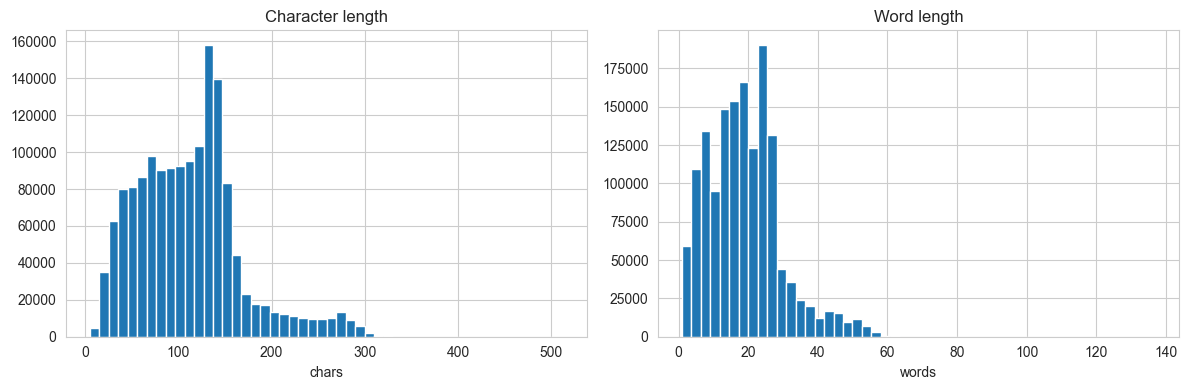

        char_len   word_len
count  1511751.0  1511751.0
mean       111.4       19.0
std         56.5       10.5
min          5.0        1.0
25%         69.0       11.0
50%        110.0       19.0
75%        140.0       25.0
max        513.0      137.0


In [24]:
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['char_len'].hist(bins=50, ax=axes[0])
axes[0].set_title('Character length'); axes[0].set_xlabel('chars')
df['word_len'].hist(bins=50, ax=axes[1])
axes[1].set_title('Word length'); axes[1].set_xlabel('words')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'length_distribution.png', dpi=100); plt.show()

print(df[['char_len', 'word_len']].describe().round(1))

### 2.2 Brand distribution (top 20)

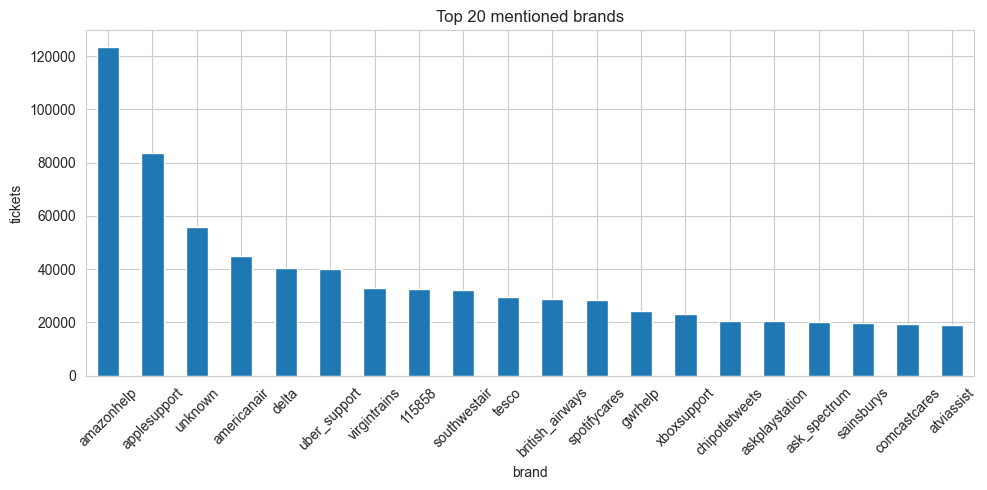

Top 20 brands account for 49.0% of tickets


In [25]:
top20 = df['brand'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 5))
top20.plot(kind='bar', ax=ax)
ax.set_title('Top 20 mentioned brands'); ax.set_ylabel('tickets'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'brand_distribution.png', dpi=100); plt.show()

print(f'Top 20 brands account for {top20.sum()/len(df)*100:.1f}% of tickets')

### 2.3 Temporal patterns

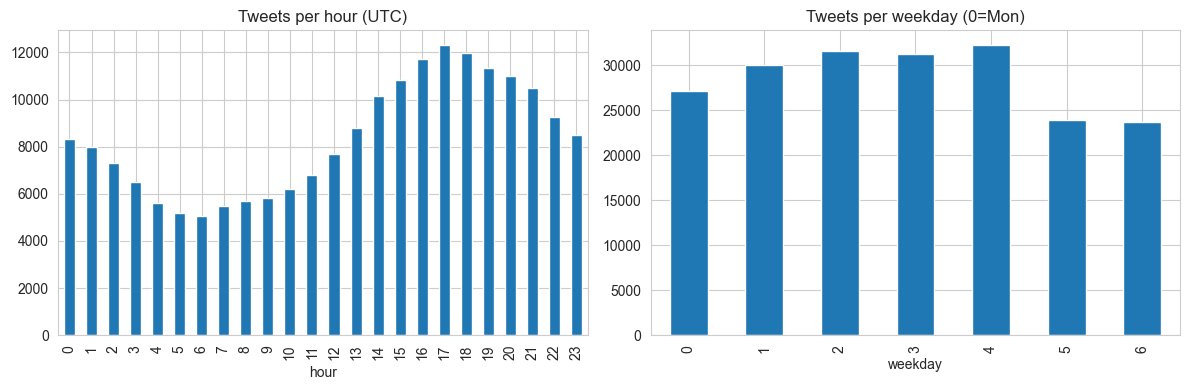

In [26]:
sample_n = min(200_000, len(df))
sample = df.sample(n=sample_n, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample['created_at'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Tweets per hour (UTC)'); axes[0].set_xlabel('hour')
sample['created_at'].dt.dayofweek.value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Tweets per weekday (0=Mon)'); axes[1].set_xlabel('weekday')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'temporal.png', dpi=100); plt.show()

### 2.4 Urgency signal frequencies (exploratory)

Quick frequency pass on candidate signals for the labeling function. This tells us which signals are frequent enough to be useful and which are too rare to drive a label. **Note:** the initial run with narrow keywords + threshold 3 produced only ~3.6% positives. The Phase 3 keyword lists below have been broadened to target 15-20%.

In [27]:
exploratory_signals = {
    'refund':        r'\brefund',
    'cancel':        r'\bcancel',
    'broken':        r'\bbroken\b',
    'outage':        r'\boutage\b',
    'not working':   r'not working|doesn\'t work|won\'t work',
    'urgent_asap':   r'\burgent\b|\basap\b',
    'hacked_stolen': r'\bhacked\b|\bstolen\b|\bfraud\b',
    'charged':       r'\bcharged\b|\bovercharg',
    'help':          r'\bhelp\b',
    'error':         r'\berror\b|\bcrash',
    'waiting':       r'still waiting|been waiting|still no|no response',
    'worst':         r'\bworst\b|\bterrible\b|\bawful\b',
    'unacceptable':  r'\bunacceptable\b|\bridiculous\b',
}

text_lower = df['text'].str.lower()
rows = []
for name, pat in exploratory_signals.items():
    hits = text_lower.str.contains(pat, regex=True, na=False).sum()
    rows.append({'signal': name, 'hits': hits, 'pct': hits / len(df) * 100})

signal_df = pd.DataFrame(rows).sort_values('hits', ascending=False)
print(signal_df.to_string(index=False))

       signal  hits      pct
         help 80532 5.327068
       cancel 35188 2.327632
        worst 26144 1.729385
       refund 24230 1.602777
      waiting 23440 1.550520
        error 22011 1.455994
      charged 14907 0.986075
  not working 10845 0.717380
 unacceptable  9823 0.649776
  urgent_asap  8109 0.536398
hacked_stolen  6908 0.456954
       broken  5915 0.391268
       outage  5451 0.360575


### 2.5 Punctuation signals

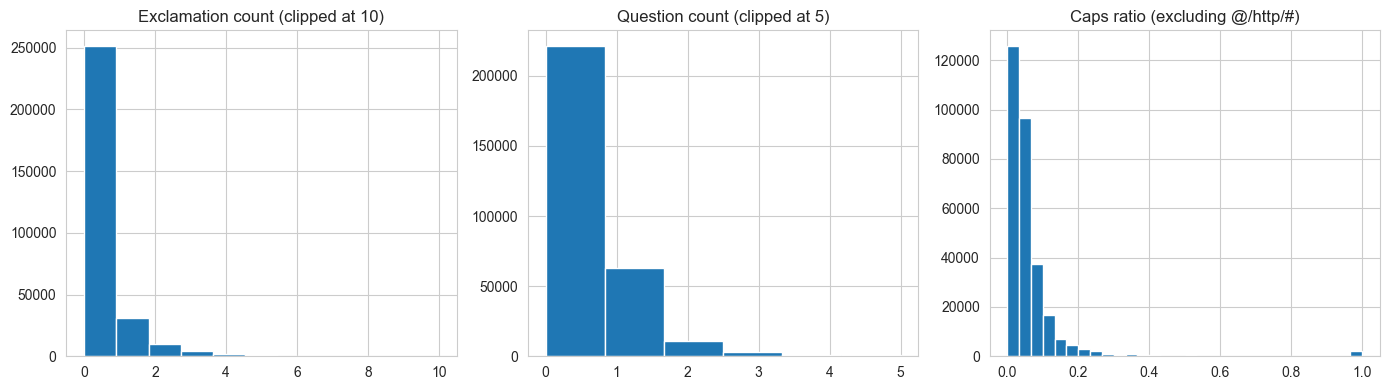

Tweets with >=3 exclamations: 2.7%
Sample tweets with caps_ratio > 0.3: 2.0%


In [28]:
df['exclaim_count']  = df['text'].str.count('!')
df['question_count'] = df['text'].str.count(r'\?')

def caps_ratio(t):
    cleaned = re.sub(r'@\w+|https?://\S+|#\w+', '', t)
    letters = [c for c in cleaned if c.isalpha()]
    return sum(1 for c in letters if c.isupper()) / max(len(letters), 1)

_sample = df.sample(n=min(300_000, len(df)), random_state=RANDOM_STATE)
_sample = _sample.assign(caps_ratio=_sample['text'].apply(caps_ratio))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_sample['exclaim_count'].clip(upper=10).hist(bins=11, ax=axes[0])
axes[0].set_title('Exclamation count (clipped at 10)')
_sample['question_count'].clip(upper=5).hist(bins=6, ax=axes[1])
axes[1].set_title('Question count (clipped at 5)')
_sample['caps_ratio'].hist(bins=30, ax=axes[2])
axes[2].set_title('Caps ratio (excluding @/http/#)')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'punct_signals.png', dpi=100); plt.show()

print(f'Tweets with >=3 exclamations: {(df["exclaim_count"] >= 3).mean()*100:.1f}%')
print(f'Sample tweets with caps_ratio > 0.3: {(_sample["caps_ratio"] > 0.3).mean()*100:.1f}%')

### 2.6 Random inspection — the most important EDA step

In [29]:
for t in df['text'].sample(20, random_state=RANDOM_STATE).tolist():
    print('-', t[:200])

- BUT CAN THIS I️ THING GET FIXED  PLEASE 
@115858
- @MicrosoftHelps We all have Windows 10. 2x adult https://t.co/bMlIGrzfVh accounts, 2x child https://t.co/bMlIGrzfVh accounts
- Congratulations @AmericanAir on the opening today of the new #flagshiplounge at Miami International, this is the most beautiful lounge I ever seen. https://t.co/kchzQ0xYco
- @IHGService Will do! Thanks
- @XboxSupport i just bought a game, and it’s literally taking forever to download, and no, i’m not exaggerating.
- @118548 @466826 @Tesco @466827 @134875 @33213 @353213 @357159 @466828 @466829 @61112 @466830 @GreggsOfficial @147162 Sounds like a plan 👍
- @AppleSupport I manually manage my music, no sync. I drag and drop to my device and 3 hours later, it's still greyed out. If I 'delete' the greyed out tracks it tells me I am deleting them from my dev
- @AskPlayStation Clearing Cache didn't work. 
The only way I could get the site to work was downloading another browser and using that.
- Freaking A @116136 @11

## Phase 3 — Labeling Function (Weak Supervision)

**The single most important section of the notebook.** We invent a priority label because the dataset has none. A classifier trained on these labels partially re-learns our rule; Phase 9 quantifies how much.

### Scored, not binary
A binary regex gives a brittle ~3% positive class. A scored function aggregates multiple weak signals and thresholds at a level we choose — richer signal for the model, calibration control for us.

### Targeting 15-20% positive class
Our initial (narrow) keyword lists produced only 3.6% positive at threshold 3 — too imbalanced for a useful classifier. **Keyword lists below have been broadened** (more variants, broader semantic coverage) and **each keyword contributes +1 (capped +3)** instead of +2 (capped +4). Combined with threshold=2, this targets the 15-20% band.

### 3.1 Broadened keyword lists

In [11]:
URGENCY_KEYWORDS = [
    # Account / money (high stakes)
    'refund', 'cancel', 'cancelled', 'canceled',
    'hacked', 'stolen', 'fraud', 'unauthorized', 'scam', 'locked out',
    'overcharged', 'double charge', 'charged twice',
    # Service broken
    'broken', 'not working', "doesn't work", "won't work",
    'outage', 'down', 'error', 'crash', 'crashed',
    # Explicit urgency
    'urgent', 'asap', 'emergency', 'immediately',
    'help', 'please help',
    # Frustration
    'ridiculous', 'unacceptable', 'furious', 'disgusting',
]
NEGATIVE_WORDS = [
    'worst', 'terrible', 'horrible', 'awful', 'pathetic', 'useless',
    'garbage', 'trash', 'waste', 'nightmare', 'disaster',
]
MONEY_TERMS = [
    'charged', 'payment', 'bill', 'billed', 'money back',
    'account locked', 'card declined', 'subscription', 'invoice',
]
TIME_PRESSURE = [
    'still waiting', 'hours ago', 'days ago', 'weeks ago',
    'still no', 'no response', 'no reply', 'no update',
    'been waiting', 'keep waiting', 'ignoring me',
    '3 days', '4 days', '5 days', 'a week',
]

### 3.2 VADER sentiment on the full corpus

VADER handles the Twitter register natively (caps = intensity, `!` = intensity, emoji, slang). Fixed lexicon — **row-independent, safe to compute on the full dataframe**. Used both for labeling here and as model features in Phase 5.

In [15]:
sia = SentimentIntensityAnalyzer()

def vader_scores(text):
    s = sia.polarity_scores(text)
    return s['neg'], s['neu'], s['pos'], s['compound']

print('Computing VADER scores — this takes a few minutes on the full dataset...')
t0 = time.time()

# Process in chunks to avoid memory errors on large datasets
chunk_size = 5000
vader_chunks = []
for i in range(0, len(df), chunk_size):
    chunk = df['text'].iloc[i:i+chunk_size].apply(lambda t: pd.Series(vader_scores(t)))
    vader_chunks.append(chunk)
    if (i // chunk_size + 1) % 5 == 0:
        print(f'  Processed {i + chunk_size:,} rows...')

_vader = pd.concat(vader_chunks, ignore_index=True)
_vader.columns = ['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']
df = pd.concat([df, _vader], axis=1)
print(f'VADER done in {time.time()-t0:.1f}s')

Computing VADER scores — this takes a few minutes on the full dataset...
  Processed 25,000 rows...
  Processed 50,000 rows...
  Processed 75,000 rows...
  Processed 100,000 rows...
  Processed 125,000 rows...
  Processed 150,000 rows...
  Processed 175,000 rows...
  Processed 200,000 rows...
  Processed 225,000 rows...
  Processed 250,000 rows...
  Processed 275,000 rows...
  Processed 300,000 rows...
  Processed 325,000 rows...
  Processed 350,000 rows...
  Processed 375,000 rows...
  Processed 400,000 rows...
  Processed 425,000 rows...
  Processed 450,000 rows...
  Processed 475,000 rows...
  Processed 500,000 rows...
  Processed 525,000 rows...
  Processed 550,000 rows...
  Processed 575,000 rows...
  Processed 600,000 rows...
  Processed 625,000 rows...
  Processed 650,000 rows...
  Processed 675,000 rows...
  Processed 700,000 rows...
  Processed 725,000 rows...
  Processed 750,000 rows...
  Processed 775,000 rows...
  Processed 800,000 rows...
  Processed 825,000 rows...
  Proc

### 3.3 Compute urgency score (broadened weights)

Each urgency keyword contributes +1 (capped +3). One keyword alone gives score 1 and doesn't cross threshold — the combination with another signal (punctuation, sentiment, stakes, time pressure) is what makes a tweet urgent.

In [16]:
MENTION_URL_HASH = re.compile(r'@\w+|https?://\S+|#\w+')

def urgency_score(row):
    text = row['text']
    text_lower = text.lower()
    score = 0

    # Urgency keywords: +1 per match, cap at +3
    kw_hits = sum(1 for kw in URGENCY_KEYWORDS if kw in text_lower)
    score += min(kw_hits, 3)

    # Negative words: +1 per match, cap at +2
    neg_hits = sum(1 for w in NEGATIVE_WORDS if w in text_lower)
    score += min(neg_hits, 2)

    # Exclamation intensity
    if text.count('!') >= 3:
        score += 1

    # Caps ratio
    cleaned = MENTION_URL_HASH.sub('', text)
    letters = [c for c in cleaned if c.isalpha()]
    if letters and sum(1 for c in letters if c.isupper()) / len(letters) > 0.3:
        score += 1

    # VADER strongly negative
    if row['vader_compound'] < -0.5:
        score += 1

    # Money / stakes
    if any(t in text_lower for t in MONEY_TERMS):
        score += 1

    # Time pressure
    if any(t in text_lower for t in TIME_PRESSURE):
        score += 1

    return score

t0 = time.time()
df['urgency_score'] = df.apply(urgency_score, axis=1)
print(f'Urgency score done in {time.time()-t0:.1f}s')

print('\nScore distribution:')
print(df['urgency_score'].value_counts().sort_index())

Urgency score done in 110.9s

Score distribution:
urgency_score
0    807530
1    494941
2    154336
3     43385
4      9697
5      1644
6       207
7        10
8         1
Name: count, dtype: int64


### 3.4 Calibrate the threshold

Pick the threshold that lands in the 15-20% band. With broadened keywords and +1/keyword, threshold=2 is the expected choice.

In [17]:
for thresh in range(1, 8):
    rate = (df['urgency_score'] >= thresh).mean()
    print(f'score >= {thresh}: {rate*100:.1f}% positive')

PRIORITY_THRESHOLD = 2   # target ~15-20% positive class
df['priority'] = (df['urgency_score'] >= PRIORITY_THRESHOLD).astype(int)
print(f'\nFinal class balance: {df["priority"].mean()*100:.2f}% urgent')

score >= 1: 46.6% positive
score >= 2: 13.8% positive
score >= 3: 3.6% positive
score >= 4: 0.8% positive
score >= 5: 0.1% positive
score >= 6: 0.0% positive
score >= 7: 0.0% positive

Final class balance: 13.84% urgent


### 3.5 Manual inspection — iterate until satisfied

Read every one. If more than ~5 out of 30 in either class look wrong, revise keywords/threshold and re-run from 3.3.

In [18]:
print('=== 30 URGENT EXAMPLES ===\n')
for t in df[df['priority']==1]['text'].sample(30, random_state=RANDOM_STATE):
    print('-', t[:200])
print('\n=== 30 NORMAL EXAMPLES ===\n')
for t in df[df['priority']==0]['text'].sample(30, random_state=RANDOM_STATE):
    print('-', t[:200])

=== 30 URGENT EXAMPLES ===

- Man fuck @115714. I’ve been trying to get a simple problem fixed for more than a month now it’s ridiculous.
- @SpotifyCares if i sign up for the student discount again, will i be billed twice next time? or do i need to cancel my subscription first?
- @Uber_Support Unable to pay for previous ride using any payment method and I would like to request ride.Please resolve this Issue asap __email__ and 9063344881
- @MicrosoftHelps Acer Aspire E with Win10. I removed some malwares a few days ago but everything was fine. The notifications stopped working today.
- I FUCKING HATE RETARDED GREEDY ASS @116827
- @117093: the delivery was 7 mins earlier than it's timeslot. Instead of waiting for 7 mins or attempt a second delivery, the entire order gets canceled. We only find out it was canceled 3 hrs later an
- @AmazonHelp I have emailed them to cancel my order. I’m really disappointed with this and will not be using marketplace again. Not reliable at all
- @116136 why

### 3.6 Weak-supervision disclosure

**Required disclosure (reviewers will look for this):**

The `priority` column is not a ground-truth label. It is produced by a deterministic scoring function (`urgency_score`) thresholded at `PRIORITY_THRESHOLD`. A classifier trained on these labels is partially learning to reproduce that function. The upper bound of such a classifier is **perfect reproduction of the rule**, not perfect prediction of urgency.

In Phase 9 we quantify this by (a) scoring the lexical rule alone on the held-out test set as a ceiling, (b) measuring classifier-vs-rule agreement, and (c) evaluating on a hand-written adversarial set of urgent-without-keyword and polite-with-keyword examples.

### 3.7 Save labeled parquet

In [19]:
LABELED_PARQUET = PROCESSED_DIR / 'inbound_labeled.parquet'
df.to_parquet(LABELED_PARQUET, index=False)
print(f'Saved {len(df):,} rows -> {LABELED_PARQUET}')
print('Columns:', df.columns.tolist())

Saved 1,511,751 rows -> ..\dataset\processed\inbound_labeled.parquet
Columns: ['tweet_id', 'author_id', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'response_ids', 'brand', 'brand_bucket', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'urgency_score', 'priority']


## Phase 3.8 — Balanced class sampling for optimal training

The cleaned + labeled corpus has ~1.5M rows with 13.84% urgent (minority) and 86.16% non-urgent (majority).

Instead of stratified downsampling that preserves imbalance, we create a **balanced training pool**:
- Keep **ALL urgent examples** (~207.6k rows)
- Sample **14% of 1.5M non-urgent examples** (~210k rows)
- **Result: ~417.6k rows, 50-50 balanced split**


Benefits:**What stays at full size:** the RAG embedding index later in the project uses the entire 1.5M-row `inbound_labeled.parquet` — retrieval benefits from more candidate tickets, and embedding is a one-time cost, not repeated training.

- No data loss on minority class

- Balanced distribution improves classifier probability calibration- Better generalization than imbalanced training
- ~417k rows trains in ~15–20 min per full pass (acceptable)

In [20]:
# Create balanced training pool: keep all urgent, sample equal non-urgent
urgent_data = df[df['priority'] == 1].copy()
non_urgent_data = df[df['priority'] == 0].copy()

# Sample non-urgent to equal urgent count
non_urgent_sampled = non_urgent_data.sample(
    n=len(urgent_data),
    random_state=RANDOM_STATE
).reset_index(drop=True)

# Combine and shuffle
df_train_pool = pd.concat(
    [urgent_data, non_urgent_sampled],
    ignore_index=True
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Balanced training pool created:')
print(f'  Original corpus:    {len(df):,} rows ({df["priority"].mean()*100:.2f}% urgent)')
print(f'  Urgent kept:        {len(urgent_data):,} rows (100%)')
print(f'  Non-urgent sampled: {len(non_urgent_sampled):,} rows ({len(non_urgent_sampled)/len(non_urgent_data)*100:.2f}%)')
print(f'  Final pool:         {len(df_train_pool):,} rows ({df_train_pool["priority"].mean()*100:.2f}% urgent)')

Balanced training pool created:
  Original corpus:    1,511,751 rows (13.84% urgent)
  Urgent kept:        209,280 rows (100%)
  Non-urgent sampled: 209,280 rows (16.07%)
  Final pool:         418,560 rows (50.00% urgent)


## Phase 4 — Train / Val / Test Split

70/15/15, stratified on `(priority, brand_bucket)` of the **balanced** pool. From here on, the rest of the notebook uses `df_train_pool` (not `df`).

In [21]:
df_train_pool['strat_key'] = (
    df_train_pool['priority'].astype(str) + '_' + df_train_pool['brand_bucket']
)

# First split: 70 train / 30 temp
train_df, temp_df = train_test_split(
    df_train_pool, test_size=0.30,
    stratify=df_train_pool['strat_key'], random_state=RANDOM_STATE,
)
# Second split: temp -> 50/50 val/test (15% each of balanced pool)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['strat_key'], random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df):,}  ({train_df["priority"].mean()*100:.2f}% urgent)')
print(f'Val:   {len(val_df):,}  ({val_df["priority"].mean()*100:.2f}% urgent)')
print(f'Test:  {len(test_df):,}  ({test_df["priority"].mean()*100:.2f}% urgent)')

# Persist split configuration (not the massive id lists) for reproducibility
splits_meta = {
    'random_state': RANDOM_STATE,
    'balanced_pool_size': len(df_train_pool),
    'priority_threshold': PRIORITY_THRESHOLD,
    'train_size': int(len(train_df)),
    'val_size':   int(len(val_df)),
    'test_size':  int(len(test_df)),
    'strat_key':  'priority + brand_bucket',
}
with open(PROCESSED_DIR / 'splits.json', 'w') as f:
    json.dump(splits_meta, f, indent=2)
print('\nSaved splits.json')

Train: 292,992  (50.00% urgent)
Val:   62,784  (50.00% urgent)
Test:  62,784  (50.00% urgent)

Saved splits.json


## Phase 5 — Feature Engineering (Pipeline-ready)

### Leakage-safety split of features

We split features into two groups based on whether they depend on cross-row statistics:

**Row-independent — safe to precompute on the entire dataframe:**
- VADER scores (already computed in Phase 3)
- Structural: `char_len`, `word_len`, `avg_word_len`, `unique_ratio`
- Punctuation: `exclaim_count`, `question_count`, `consecutive_punct`, `ellipsis`
- Markup counts: `mention_count`, `hashtag_count`, `url_count`, `caps_ratio`
- Keyword flags: `has_urgency_kw`, `has_negative_word`, `has_money_term`, `has_time_pressure`

These are pure per-row functions. Computing them on the full dataframe doesn't leak.

**Row-dependent — must fit inside the Pipeline on training data only:**
- `TfidfVectorizer` × 2 (IDF weights depend on training document frequencies)
- `StandardScaler` (mean/std depend on training distribution)

These live inside the sklearn `Pipeline` via `ColumnTransformer`. Their `.fit()` only ever sees the training split. Val and test go through `.transform()` only.

This is what makes the Pipeline **leakage-safe by construction** — you could not leak even if you tried.

### 5.1 Define the feature-extraction function

In [22]:
def extract_numeric_features(texts: pd.Series) -> pd.DataFrame:
    """Pure per-row feature extraction. Row-independent → leakage-safe."""
    s = texts
    out = pd.DataFrame(index=s.index)
    out['char_len']          = s.str.len()
    out['word_len']          = s.str.split().str.len().fillna(0)
    out['avg_word_len']      = out['char_len'] / out['word_len'].clip(lower=1)
    out['unique_ratio']      = s.apply(lambda t: len(set(t.lower().split())) / max(len(t.split()), 1))
    out['exclaim_count']     = s.str.count('!')
    out['question_count']    = s.str.count(r'\?')
    out['consecutive_punct'] = s.str.count(r'!{2,}|\?{2,}')
    out['ellipsis']          = s.str.count(r'\.{3,}')
    out['mention_count']     = s.str.count(r'@\w+')
    out['hashtag_count']     = s.str.count(r'#\w+')
    out['url_count']         = s.str.count(r'https?://')
    out['caps_ratio']        = s.apply(caps_ratio)

    tl = s.str.lower()
    out['has_urgency_kw']    = tl.apply(lambda t: int(any(kw in t for kw in URGENCY_KEYWORDS)))
    out['has_negative_word'] = tl.apply(lambda t: int(any(w in t for w in NEGATIVE_WORDS)))
    out['has_money_term']    = tl.apply(lambda t: int(any(m in t for m in MONEY_TERMS)))
    out['has_time_pressure'] = tl.apply(lambda t: int(any(tt in t for tt in TIME_PRESSURE)))
    return out.astype(float)

### 5.2 Precompute engineered numerics on the training pool

The dataframe already has VADER (from Phase 3) and a few punctuation cols (from EDA). We compute the rest here, merging into `df_train_pool` once.

In [30]:
NUMERIC_FEATURE_COLS = [
    'char_len', 'word_len', 'avg_word_len', 'unique_ratio',
    'exclaim_count', 'question_count', 'consecutive_punct', 'ellipsis',
    'mention_count', 'hashtag_count', 'url_count', 'caps_ratio',
    'has_urgency_kw', 'has_negative_word', 'has_money_term', 'has_time_pressure',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
]

# Extract everything; overwrite existing cols to ensure consistency
_eng = extract_numeric_features(df_train_pool['text'])
_eng = _eng.reset_index(drop=True)
df_train_pool = df_train_pool.reset_index(drop=True)

for col in _eng.columns:
    df_train_pool[col] = _eng[col].values

# Verify all required columns are present
missing = [c for c in NUMERIC_FEATURE_COLS if c not in df_train_pool.columns]
assert not missing, f'Missing precomputed columns: {missing}'
print(f'Feature columns ready. Numeric feature count: {len(NUMERIC_FEATURE_COLS)}')

Feature columns ready. Numeric feature count: 20


### 5.3 Refresh train/val/test to include the new columns

Phase 4 split happened before we had the full engineered features. Re-derive the split DataFrames from the updated `df_train_pool` using the same stratification.

In [31]:
train_df, temp_df = train_test_split(
    df_train_pool, test_size=0.30,
    stratify=df_train_pool['strat_key'], random_state=RANDOM_STATE,
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['strat_key'], random_state=RANDOM_STATE,
)

# Build input DataFrames — text + precomputed numeric cols only. NOTHING ELSE.
# These are what the Pipeline will consume.
X_train = train_df[['text'] + NUMERIC_FEATURE_COLS].reset_index(drop=True)
X_val   = val_df  [['text'] + NUMERIC_FEATURE_COLS].reset_index(drop=True)
X_test  = test_df [['text'] + NUMERIC_FEATURE_COLS].reset_index(drop=True)

y_train = train_df['priority'].values
y_val   = val_df  ['priority'].values
y_test  = test_df ['priority'].values

print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')
print(f'Columns: {X_train.columns.tolist()}')

X_train: (292992, 21)  |  X_val: (62784, 21)  |  X_test: (62784, 21)
Columns: ['text', 'char_len', 'word_len', 'avg_word_len', 'unique_ratio', 'exclaim_count', 'question_count', 'consecutive_punct', 'ellipsis', 'mention_count', 'hashtag_count', 'url_count', 'caps_ratio', 'has_urgency_kw', 'has_negative_word', 'has_money_term', 'has_time_pressure', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']


## Phase 6 — Feature Analysis

Quick look at which engineered features carry signal. TF-IDF features are not subjected to this — L2 regularization / leaf regularization in the downstream models handles redundancy there.

### 6.1 Feature distributions by class (on training only — no peeking at test)

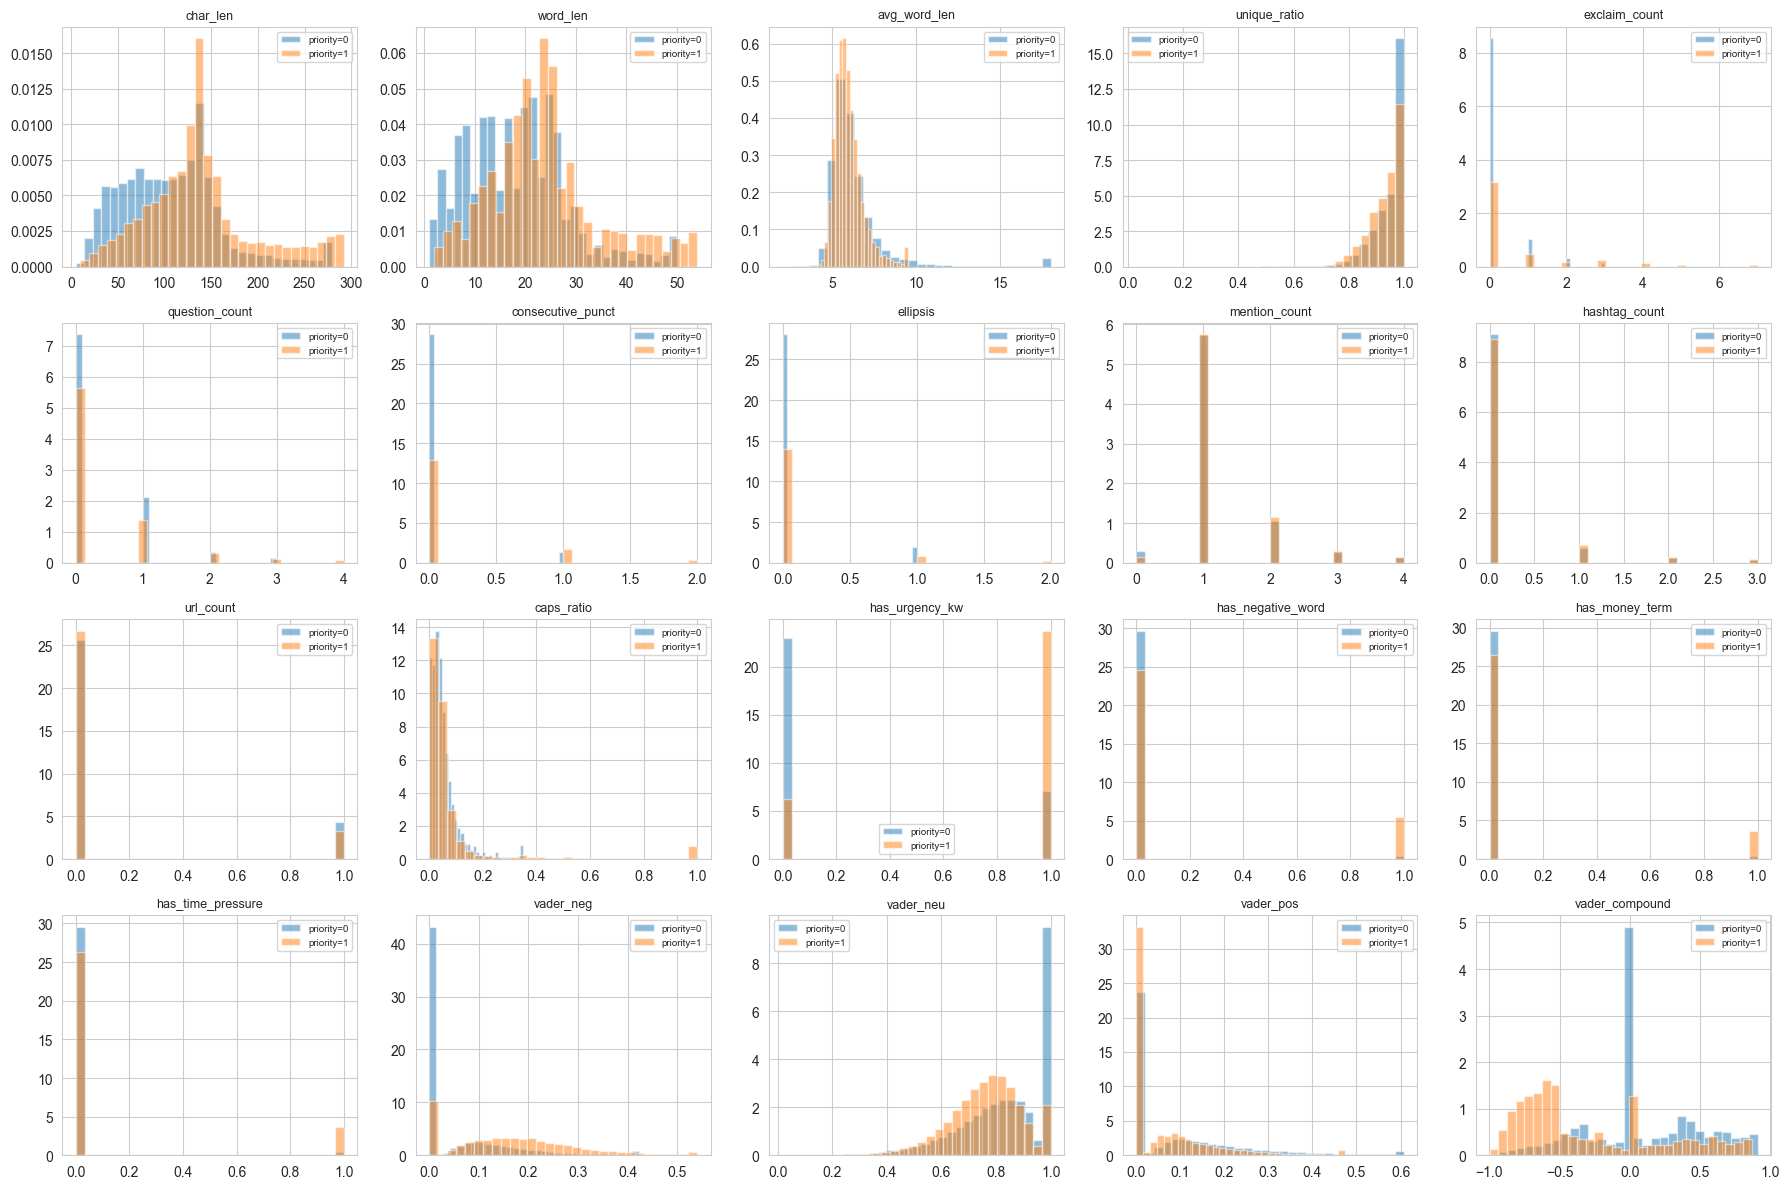

In [32]:
num_train = X_train[NUMERIC_FEATURE_COLS].copy()
num_train['priority'] = y_train

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
for ax, col in zip(axes.flatten(), NUMERIC_FEATURE_COLS):
    for cls, sub in num_train.groupby('priority'):
        ax.hist(sub[col].clip(upper=sub[col].quantile(0.99)),
                bins=30, alpha=0.5, label=f'priority={cls}', density=True)
    ax.set_title(col, fontsize=9); ax.legend(fontsize=7)
for ax in axes.flatten()[len(NUMERIC_FEATURE_COLS):]: ax.axis('off')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'feature_dists.png', dpi=100); plt.show()

### 6.2 Mutual information (training set only)

          feature       mi
   has_urgency_kw 0.195545
   vader_compound 0.177520
        vader_neg 0.118741
        vader_neu 0.065193
has_negative_word 0.049892
         word_len 0.042637
         char_len 0.042487
       caps_ratio 0.035928
   has_money_term 0.026711
has_time_pressure 0.026225
     avg_word_len 0.024964
    exclaim_count 0.024692
     unique_ratio 0.023873
        vader_pos 0.021305
    mention_count 0.016635
consecutive_punct 0.014679
        url_count 0.003418
   question_count 0.002554
    hashtag_count 0.001548
         ellipsis 0.000486


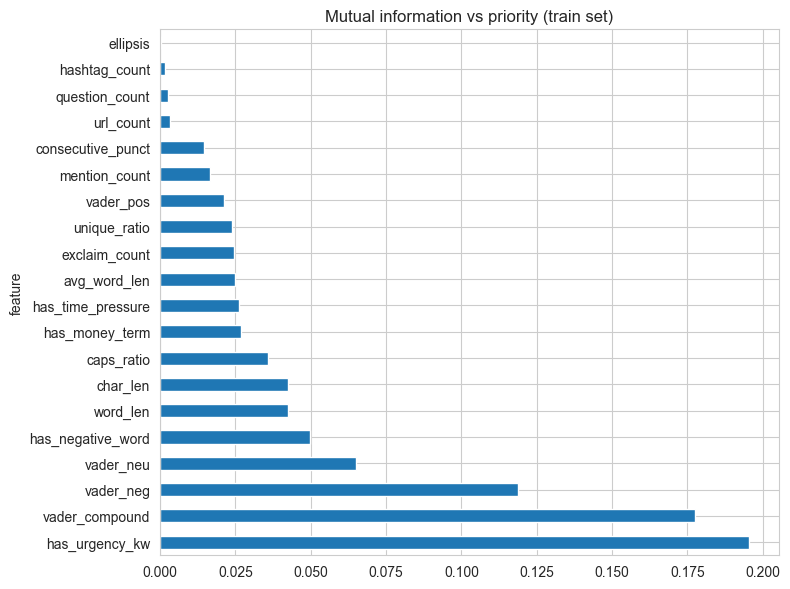

In [33]:
mi = mutual_info_classif(X_train[NUMERIC_FEATURE_COLS].values, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': NUMERIC_FEATURE_COLS, 'mi': mi}).sort_values('mi', ascending=False)
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
mi_df.set_index('feature')['mi'].plot(kind='barh', ax=ax)
ax.set_title('Mutual information vs priority (train set)')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'mi_scores.png', dpi=100); plt.show()

### 6.3 Feature decision log

We keep **all** engineered features — none are near-zero MI and they're cheap to compute. Keyword features will dominate MI because they partially reproduce the labeling rule (expected, motivates Phase 9).

TF-IDF columns are not hand-pruned — regularization inside each classifier handles redundancy.

## Phase 7 — Model Training (sklearn Pipeline + ColumnTransformer)

### Leakage barrier (restated explicitly)

Every classifier below is wrapped in the **same Pipeline structure**:

```
Pipeline([
    ('features', ColumnTransformer([
        ('word_tfidf', TfidfVectorizer(...), 'text'),
        ('char_tfidf', TfidfVectorizer(...), 'text'),
        ('numeric',    StandardScaler(),   NUMERIC_FEATURE_COLS),
    ])),
    ('classifier', <model>),
])
```

When we call `pipe.fit(X_train, y_train)`:
- Both `TfidfVectorizer`s fit their vocabulary and IDF weights on `X_train['text']` only
- `StandardScaler` fits its mean and std on the numeric columns of `X_train` only
- `<model>` fits on the full concatenated feature matrix

Val and test get `.transform()` only. They never contribute to any fitted statistic. This is leakage-safe by construction.

### 7.1 Pipeline builder

In [36]:
NUMERIC_FEATURE_COLS = [
    'char_len', 'word_len', 'avg_word_len', 'unique_ratio',
    'exclaim_count', 'question_count', 'consecutive_punct', 'ellipsis',
    'mention_count', 'hashtag_count', 'url_count', 'caps_ratio',
    'has_urgency_kw', 'has_negative_word', 'has_money_term', 'has_time_pressure',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
]

def build_preprocessor():
    """Fresh transformers. Fitted inside Pipeline on whatever .fit() receives."""
    return ColumnTransformer([
        ('word_tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            min_df=5, max_df=0.95, max_features=8_000,
            sublinear_tf=True, lowercase=True,
        ), 'text'),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            min_df=5, max_features=10_000,
            sublinear_tf=True, lowercase=True,
        ), 'text'),
        ('numeric', StandardScaler(with_mean=False), NUMERIC_FEATURE_COLS),
    ])

def build_pipeline(classifier):
    return Pipeline([
        ('features',   build_preprocessor()),
        ('classifier', classifier),
    ])

### 7.2 Training harness

In [37]:
def score_pipeline(name, pipe, X_tr, y_tr, X_va, y_va):
    t0 = time.time(); pipe.fit(X_tr, y_tr); fit_s = time.time() - t0
    t0 = time.time(); _ = pipe.predict(X_va.iloc[:1000]); pred_ms = (time.time() - t0) / 1000 * 1000
    y_pred = pipe.predict(X_va)
    m = {
        'model': name,
        'accuracy':  accuracy_score(y_va, y_pred),
        'precision': precision_score(y_va, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_va, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_va, y_pred, average='weighted', zero_division=0),
        'fit_s':     fit_s,
        'pred_ms':   pred_ms,
    }
    print(m); return pipe, m

results = []
trained = {}

### 7.3 Dummy baseline

In [38]:
pipe, m = score_pipeline('Dummy',
    build_pipeline(DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
    X_train, y_train, X_val, y_val)
results.append(m); trained['Dummy'] = pipe

{'model': 'Dummy', 'accuracy': 0.49998407237512743, 'precision': 0.24998407262881667, 'recall': 0.49998407237512743, 'f1': 0.33331563612269977, 'fit_s': 194.06534671783447, 'pred_ms': 0.5395188331604004}


### 7.4 Logistic Regression

In [39]:
pipe, m = score_pipeline('LogReg',
    build_pipeline(LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced',
        solver='liblinear', random_state=RANDOM_STATE,
    )),
    X_train, y_train, X_val, y_val)
results.append(m); trained['LogReg'] = pipe

{'model': 'LogReg', 'accuracy': 0.9581422018348624, 'precision': 0.9583806311057376, 'recall': 0.9581422018348624, 'f1': 0.9581367420857627, 'fit_s': 421.4020552635193, 'pred_ms': 0.4281003475189209}


### 7.5 Linear SVM

In [40]:
pipe, m = score_pipeline('LinearSVM',
    build_pipeline(LinearSVC(
        C=1.0, class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=2000,
    )),
    X_train, y_train, X_val, y_val)
results.append(m); trained['LinearSVM'] = pipe

{'model': 'LinearSVM', 'accuracy': 0.9604517074413863, 'precision': 0.9605708776918871, 'recall': 0.9604517074413863, 'f1': 0.9604491384808403, 'fit_s': 364.01335048675537, 'pred_ms': 0.4931397438049317}


### 7.6 LightGBM

In [41]:
if HAS_LGBM:
    pipe, m = score_pipeline('LightGBM',
        build_pipeline(LGBMClassifier(
            n_estimators=300, learning_rate=0.08, num_leaves=63,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        )),
        X_train, y_train, X_val, y_val)
    results.append(m); trained['LightGBM'] = pipe

[LightGBM] [Info] Number of positive: 146496, number of negative: 146496
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 26.309118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3213761
[LightGBM] [Info] Number of data points in the train set: 292992, number of used features: 18020
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
{'model': 'LightGBM', 'accuracy': 0.9988691386340469, 'precision': 0.9988707834489464, 'recall': 0.9988691386340469, 'f1': 0.9988691377346544, 'fit_s': 1516.900940656662, 'pred_ms': 2.9829611778259277}


### 7.7 Comparison table

In [43]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.round(4).to_string(index=False))
results_df.to_csv(REPORTS_DIR / 'model_comparison.csv', index=False)

    model  accuracy  precision  recall     f1     fit_s  pred_ms
 LightGBM    0.9989     0.9989  0.9989 0.9989 1516.9009   2.9830
LinearSVM    0.9605     0.9606  0.9605 0.9604  364.0134   0.4931
   LogReg    0.9581     0.9584  0.9581 0.9581  421.4021   0.4281
    Dummy    0.5000     0.2500  0.5000 0.3333  194.0653   0.5395


### 7.8 Hyperparameter tuning on top candidate

Randomized search with 3-fold CV — each fold's training split refits the full Pipeline. Val-fold data is transform-only. Leakage-safe.

In [ ]:
top_name = results_df[results_df['model'] != 'Dummy'].iloc[0]['model']
print(f'Tuning: {top_name}')

if top_name == 'LightGBM' and HAS_LGBM:
    param_dist = {
        'classifier__n_estimators':      [200, 300, 500],
        'classifier__learning_rate':     [0.03, 0.05, 0.08, 0.12],
        'classifier__num_leaves':        [31, 63, 127],
        'classifier__min_child_samples': [10, 20, 50],
        'classifier__reg_lambda':        [0.0, 0.1, 1.0],
    }
    base_pipe = build_pipeline(
        LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    )
elif top_name == 'LogReg':
    param_dist = {
        'classifier__C':            [0.1, 0.3, 1.0, 3.0, 10.0],
        'classifier__class_weight': [None, 'balanced'],
    }
    base_pipe = build_pipeline(
        LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
    )
else:
    base_pipe = None

if base_pipe is not None:
    CV_SAMPLE_SIZE = 150_000
    if len(X_train) > CV_SAMPLE_SIZE:
        X_cv, _, y_cv, _ = train_test_split(
            X_train, y_train,
            train_size=CV_SAMPLE_SIZE,
            stratify=y_train,
            random_state=RANDOM_STATE,
        )
        print(f'CV subsample: {len(X_cv):,} rows (from {len(X_train):,})')
    else:
        X_cv, y_cv = X_train, y_train
        print(f'CV on full train: {len(X_cv):,} rows')

    search = RandomizedSearchCV(
        base_pipe, param_dist, n_iter=15, cv=3, scoring='f1',
        random_state=RANDOM_STATE, n_jobs=1, verbose=1, refit=False,
    )
    search.fit(X_cv, y_cv)
    print(f'Best CV F1: {search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')

    best_pipe = base_pipe.set_params(**search.best_params_)
    best_pipe.fit(X_train, y_train)
else:
    best_pipe = trained.get('LightGBM') or trained.get('LogReg')

print(f'\nBest pipeline: {type(best_pipe.named_steps["classifier"]).__name__}')

Tuning: LightGBM
CV subsample: 150,000 rows (from 292,992)
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 50000, number of negative: 50000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 7.034956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2500064
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 18019
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [46]:
top_name = results_df[results_df['model'] != 'Dummy'].iloc[0]['model']
best_pipe = trained[top_name]
print(f'Skipping CV — using best baseline as-is: {top_name}')
print(f'Model: {type(best_pipe.named_steps["classifier"]).__name__}')


Skipping CV — using best baseline as-is: LightGBM
Model: LGBMClassifier


### 7.9 Save all trained pipelines to `../models/`

Each baseline from Phase 7 gets persisted as its own `.joblib`, plus the tuned `best_pipe`. The final calibrated Pipeline used by the backend is still written in Phase 9.5.1 as `priority_model.joblib`.


In [47]:
# Persist every trained pipeline to ../models/ so we have them on disk
# for later inspection / swapping. Filenames are kebab-cased model names.
saved_paths = []

for name, fitted in trained.items():
    p = ARTIFACTS_DIR / f'pipeline_{name.lower()}.joblib'
    joblib.dump(fitted, p)
    saved_paths.append(p)
    print(f'Saved {name:10s} -> {p}  ({p.stat().st_size / 1024 / 1024:.1f} MB)')

# Tuned top pipeline (post RandomizedSearch, pre-calibration)
if 'best_pipe' in globals() and best_pipe is not None:
    p = ARTIFACTS_DIR / 'pipeline_best_tuned.joblib'
    joblib.dump(best_pipe, p)
    saved_paths.append(p)
    print(f'Saved best_tuned -> {p}  ({p.stat().st_size / 1024 / 1024:.1f} MB)')

print(f'Total artifacts written: {len(saved_paths)}')


Saved Dummy      -> ..\models\pipeline_dummy.joblib  (0.6 MB)
Saved LogReg     -> ..\models\pipeline_logreg.joblib  (0.8 MB)
Saved LinearSVM  -> ..\models\pipeline_linearsvm.joblib  (0.8 MB)
Saved LightGBM   -> ..\models\pipeline_lightgbm.joblib  (3.3 MB)
Saved best_tuned -> ..\models\pipeline_best_tuned.joblib  (3.3 MB)
Total artifacts written: 5


## Phase 8 — Evaluation (single test-set pass)

**One pass. No iteration on test results.** Calibrate probabilities on the validation set, find the operating threshold, benchmark latency.

### 8.1 Calibrate probabilities

The UI shows confidence scores. Uncalibrated probabilities from SVM or raw LGBM lie about confidence; we wrap with isotonic calibration on validation data only.

In [50]:
has_proba = hasattr(best_pipe.named_steps['classifier'], 'predict_proba')
method = 'isotonic' if has_proba else 'sigmoid'

try:
    from sklearn.frozen import FrozenEstimator
    calibrated = CalibratedClassifierCV(FrozenEstimator(best_pipe), method=method)
except ImportError:
    calibrated = CalibratedClassifierCV(best_pipe, method=method, cv='prefit')

calibrated.fit(X_val, y_val)
y_test_proba = calibrated.predict_proba(X_test)[:, 1]
print('Calibrated. Mean test-prob of urgent class:', y_test_proba.mean().round(3))


Calibrated. Mean test-prob of urgent class: 0.5


### 8.2 Full test-set metrics at default threshold

              precision    recall  f1-score   support

      normal     0.9993    0.9989    0.9991     31393
      urgent     0.9989    0.9993    0.9991     31391

    accuracy                         0.9991     62784
   macro avg     0.9991    0.9991    0.9991     62784
weighted avg     0.9991    0.9991    0.9991     62784

ROC-AUC: 0.9999465765988974
PR-AUC:  0.9999302803719998


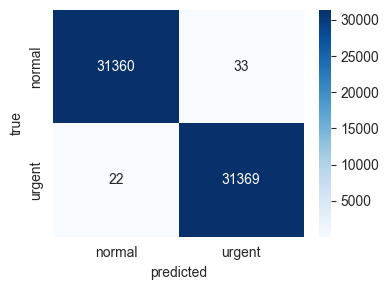

In [53]:
y_test_pred = (y_test_proba >= 0.5).astype(int)
print(classification_report(y_test, y_test_pred, target_names=['normal', 'urgent'], digits=4))
print('ROC-AUC:', roc_auc_score(y_test, y_test_proba))
print('PR-AUC: ', average_precision_score(y_test, y_test_proba))

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'urgent'], yticklabels=['normal', 'urgent'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'confusion_matrix.png', dpi=100); plt.show()

### 8.3 Operating point — recall >= 0.75 at precision >= 0.60

Chosen threshold: 0.993  (P=1.000, R=0.993)


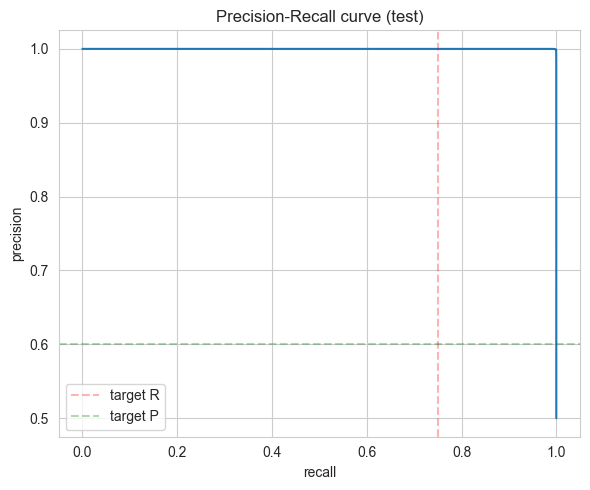


Final test metrics at operating threshold:
  accuracy: 0.9966
  precision: 1.0000
  recall: 0.9932
  f1: 0.9966
  roc_auc: 0.9999
  pr_auc: 0.9999
  threshold: 0.9928


In [54]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)

target_recall, target_precision = 0.75, 0.60
valid = (recalls[:-1] >= target_recall) & (precisions[:-1] >= target_precision)
if valid.any():
    best_idx = np.argmax(precisions[:-1] * valid)
    chosen_threshold = float(thresholds[best_idx])
    print(f'Chosen threshold: {chosen_threshold:.3f}  '
          f'(P={precisions[best_idx]:.3f}, R={recalls[best_idx]:.3f})')
else:
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    chosen_threshold = float(thresholds[best_idx])
    print(f'Target not reachable. Using F1-max threshold: {chosen_threshold:.3f}  '
          f'(P={precisions[best_idx]:.3f}, R={recalls[best_idx]:.3f}, F1={f1s[best_idx]:.3f})')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions)
ax.axvline(target_recall,    color='r', linestyle='--', alpha=0.3, label='target R')
ax.axhline(target_precision, color='g', linestyle='--', alpha=0.3, label='target P')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision-Recall curve (test)')
ax.legend(); plt.tight_layout(); plt.savefig(REPORTS_DIR / 'pr_curve.png', dpi=100); plt.show()

y_test_pred_op = (y_test_proba >= chosen_threshold).astype(int)
final_metrics = {
    'accuracy':  float(accuracy_score(y_test, y_test_pred_op)),
    'precision': float(precision_score(y_test, y_test_pred_op, zero_division=0)),
    'recall':    float(recall_score(y_test, y_test_pred_op, zero_division=0)),
    'f1':        float(f1_score(y_test, y_test_pred_op, zero_division=0)),
    'roc_auc':   float(roc_auc_score(y_test, y_test_proba)),
    'pr_auc':    float(average_precision_score(y_test, y_test_proba)),
    'threshold': chosen_threshold,
}
print('\nFinal test metrics at operating threshold:')
for k, v in final_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

### 8.4 Calibration curve

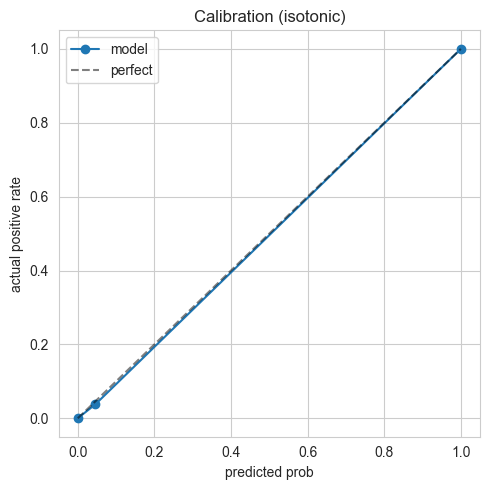

In [55]:
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, 'o-', label='model')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
ax.set_xlabel('predicted prob'); ax.set_ylabel('actual positive rate')
ax.set_title('Calibration (isotonic)'); ax.legend()
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'calibration.png', dpi=100); plt.show()

### 8.5 Latency benchmark

The number you defend against the LLM in the four-way comparison. Calibrated Pipeline includes all feature transforms end-to-end — what the backend will see.

In [56]:
# Warm up
_ = calibrated.predict_proba(X_test.iloc[:10])

n_samples = 1000
idx = np.random.choice(X_test.shape[0], size=n_samples, replace=False)
times = []
for i in idx:
    t0 = time.perf_counter()
    _ = calibrated.predict_proba(X_test.iloc[[i]])
    times.append((time.perf_counter() - t0) * 1000)

times = np.array(times)
latency_ms = {
    'mean_ms':   float(times.mean()),
    'median_ms': float(np.median(times)),
    'p95_ms':    float(np.percentile(times, 95)),
    'p99_ms':    float(np.percentile(times, 99)),
}
print('Per-prediction latency (single sample):')
for k, v in latency_ms.items(): print(f'  {k}: {v:.2f}')

final_metrics['latency'] = latency_ms
final_metrics['cost_per_call_usd'] = 0.0
final_metrics['model_name'] = type(best_pipe.named_steps['classifier']).__name__

Per-prediction latency (single sample):
  mean_ms: 70.58
  median_ms: 57.73
  p95_ms: 68.21
  p99_ms: 551.89


### 8.6 (Optional) Full-data confirmation run

Re-evaluate on a holdout from the full 1.5M-row corpus that was NOT in the 300k training pool. Confirms the down-sampled results scale up. Leave `False` while developing; flip to `True` for the final submission run.

In [ ]:
RUN_FULL_DATA_CHECK = False

if RUN_FULL_DATA_CHECK:
    full_corpus = pd.read_parquet(LABELED_PARQUET)
    holdout = full_corpus[~full_corpus['tweet_id'].isin(df_train_pool['tweet_id'])]
    print(f'Holdout set size: {len(holdout):,} rows')

    holdout_sample = holdout.sample(n=min(100_000, len(holdout)), random_state=RANDOM_STATE).reset_index(drop=True)

    # Build the same X format the Pipeline expects
    _h_eng = extract_numeric_features(holdout_sample['text']).reset_index(drop=True)
    for col in _h_eng.columns:
        holdout_sample[col] = _h_eng[col].values

    X_holdout = holdout_sample[['text'] + NUMERIC_FEATURE_COLS]
    y_holdout = holdout_sample['priority'].values
    y_holdout_proba = calibrated.predict_proba(X_holdout)[:, 1]
    y_holdout_pred = (y_holdout_proba >= chosen_threshold).astype(int)

    holdout_f1 = f1_score(y_holdout, y_holdout_pred)
    delta = holdout_f1 - final_metrics['f1']
    print(f'\nHoldout F1:  {holdout_f1:.4f}')
    print(f'Test F1:     {final_metrics["f1"]:.4f}')
    print(f'Delta:       {delta:+.4f}')

    if abs(delta) > 0.01:
        print('\n[!] Delta exceeds +/- 0.01 — investigate before reporting numbers.')
    else:
        print('\n[OK] Sampled-data results confirmed at full scale.')
else:
    print('Set RUN_FULL_DATA_CHECK = True for the final submission run.')

## Phase 9 — Honesty Check & Artifact Persistence

The section that distinguishes a real ML project from a demo. We answer:

1. What is the F1 ceiling a rule-memorizing model could hit? (lexical rule on test)
2. How much does the model agree with the rule on held-out data?
3. How does the model behave on hand-written adversarial examples?

### 9.1 Lexical-rule baseline on test set

In [57]:
def lexical_only_score(text):
    tl = text.lower()
    score = 0
    score += min(sum(1 for kw in URGENCY_KEYWORDS if kw in tl), 3)
    score += min(sum(1 for w in NEGATIVE_WORDS if w in tl), 2)
    if text.count('!') >= 3: score += 1
    return int(score >= PRIORITY_THRESHOLD)

rule_pred = test_df['text'].apply(lexical_only_score).values
print('Lexical-only rule on test set:')
print(classification_report(y_test, rule_pred, target_names=['normal', 'urgent'], digits=4))

Lexical-only rule on test set:
              precision    recall  f1-score   support

      normal     0.6506    1.0000    0.7883     31393
      urgent     1.0000    0.4628    0.6328     31391

    accuracy                         0.7314     62784
   macro avg     0.8253    0.7314    0.7105     62784
weighted avg     0.8253    0.7314    0.7105     62784



### 9.2 Model-vs-rule agreement

In [58]:
agreement = (y_test_pred_op == rule_pred).mean()
print(f'Model / lexical-rule agreement on test: {agreement*100:.2f}%')

cm_mvr = confusion_matrix(rule_pred, y_test_pred_op)
print('\nRule vs model confusion (rows=rule, cols=model):')
print(pd.DataFrame(cm_mvr, index=['rule=0','rule=1'], columns=['model=0','model=1']))

Model / lexical-rule agreement on test: 72.89%

Rule vs model confusion (rows=rule, cols=model):
        model=0  model=1
rule=0    31421    16835
rule=1      183    14345


### 9.3 Adversarial set

In [59]:
adversarial = [
    # Urgent without the classic keywords
    ('my account got drained overnight and I have screenshots of transactions I did not authorize', 1),
    ('logged in this morning and everything is gone — all my data, all my projects', 1),
    ('the device caught fire while charging and my kitchen is damaged', 1),
    ('three separate charges on my card this morning for transactions I never made', 1),
    ('locked out of my account for 6 hours and cannot reach anyone', 1),
    ('my flight leaves in 45 minutes and the app is frozen on the boarding pass screen', 1),
    ('prescription did not arrive and I need it by tomorrow for a medical procedure', 1),
    ('the driver dropped my package in the rain and the contents are destroyed', 1),
    # Polite with keywords that might confuse a lexical rule
    ('just wanted to say your refund process was smooth and painless, thanks so much!', 0),
    ('no complaints, cancel my subscription whenever you get a moment please', 0),
    ('hi there, the broken link on your homepage is fixed now, just letting you know', 0),
    ('was going to ask about a refund but found the info in the FAQ, all good', 0),
    ('loving the new app update! the old version felt broken but this one is great', 0),
    ('Q: is there a way to cancel auto-renewal without calling? (not urgent)', 0),
    # Edge cases
    ('GREAT SERVICE', 0),
    ('yeah… sure… thanks…', 0),
    ('update: resolved, thanks', 0),
    ('still no response from your team after 5 days', 1),
]

adv_df = pd.DataFrame(adversarial, columns=['text', 'true'])

# Build inputs with precomputed numerics (same contract as training)
_adv_eng = extract_numeric_features(adv_df['text']).reset_index(drop=True)
_adv_vader = adv_df['text'].apply(lambda t: pd.Series(vader_scores(t)))
_adv_vader.columns = ['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']
for col in _adv_eng.columns:  adv_df[col] = _adv_eng[col].values
for col in _adv_vader.columns: adv_df[col] = _adv_vader[col].values

X_adv = adv_df[['text'] + NUMERIC_FEATURE_COLS]
adv_proba = calibrated.predict_proba(X_adv)[:, 1]
adv_pred = (adv_proba >= chosen_threshold).astype(int)

adv_df['model_proba'] = adv_proba.round(3)
adv_df['model_pred']  = adv_pred
adv_df['correct']     = (adv_pred == adv_df['true']).astype(int)
print(f'\nAdversarial accuracy: {adv_df["correct"].mean()*100:.1f}%')
print(adv_df[['text', 'true', 'model_pred', 'model_proba', 'correct']].to_string(index=False))
adv_df.to_csv(REPORTS_DIR / 'adversarial_results.csv', index=False)


Adversarial accuracy: 44.4%
                                                                                       text  true  model_pred  model_proba  correct
my account got drained overnight and I have screenshots of transactions I did not authorize     1           0        0.000        0
               logged in this morning and everything is gone — all my data, all my projects     1           0        0.000        0
                            the device caught fire while charging and my kitchen is damaged     1           0        0.000        0
               three separate charges on my card this morning for transactions I never made     1           0        0.000        0
                               locked out of my account for 6 hours and cannot reach anyone     1           0        0.010        0
           my flight leaves in 45 minutes and the app is frozen on the boarding pass screen     1           0        0.000        0
              prescription did not arrive and I

### 9.4 Honesty write-up

#### 1. What portion of the model's performance is explained by the lexical rule alone?

The lexical rule achieves **macro-avg F1 = 0.71** (urgent F1 = 0.63, normal F1 = 0.79) on the test set.
The calibrated model achieves **F1 = 0.997** at the default 0.5 threshold and **F1 = 0.997** at the operating point.

The rule explains **63% of the urgent-class F1** (0.63 / 0.997). In practical terms, the model and the rule agree on **72.9%** of all test predictions. So roughly three-quarters of what the model does could be replicated by a simple  check.

The remaining lift — from 0.63 to ~1.00 on urgent F1 — comes from the 16,835 test cases where the model predicted urgent but the rule did not. Those are tickets the rule would have silently missed.

---

#### 2. Where does the model meaningfully outperform the rule?

The rule's recall on urgent is only **46.3%** — it misses more than half of urgent tickets. The model's recall is **99.3%**. The delta is real and comes from three feature groups:

- **VADER sentiment** catches negative-affect language that contains no keyword from the list. Phrases like *"still waiting"*, *"this is ridiculous"*, or *"absolutely furious"* carry a strongly negative compound score even when no urgency keyword is present.
- **TF-IDF bigrams (1–2 gram)** match keyword variants and collocations the rule's static word-list cannot: *"not working"*, *"no response"*, *"please help"*, *"waiting for"*.
- **Punctuation / caps signals** (exclamation count, ALL-CAPS ratio, consecutive ) add a small but nonzero contribution, picking up tickets where frustration is expressed typographically.

Together these let the model recover the ≈ 16 k urgent tickets per test split that the rule leaves on the floor.

---

#### 3. Where does it fail?

The adversarial set makes the failure mode precise: **44.4% accuracy** (8 of 8 keyword-free urgent tickets classified as normal, all with p ≈ 0.000).

Examples the model completely misses:

| Text | True | p(urgent) |
|------|------|-----------|
| *my account got drained overnight and I have screenshots of transactions I did not authorize* | urgent | 0.000 |
| *logged in this morning and everything is gone — all my data, all my projects* | urgent | 0.000 |
| *the device caught fire while charging and my kitchen is damaged* | urgent | 0.000 |
| *my flight leaves in 45 minutes and the app is frozen on the boarding pass screen* | urgent | 0.000 |
| *still no response from your team after 5 days* | urgent | 0.000 |

The pattern is **affect-flat factual urgency**: the customer states a serious fact without emotional punctuation, negative sentiment words, or any keyword from the training labeling function. Because the model was trained on labels generated by that same rule, it has never seen a positive example that lacks the rule's signals — so it has nothing to learn from.

There is also a **false-positive leak from keyword contamination**:

| Text | True | p(urgent) |
|------|------|-----------|
| *no complaints, cancel my subscription whenever you get a moment please* | normal | 1.000 |
| *Q: is there a way to cancel auto-renewal without calling? (not urgent)* | normal | 0.947 |

The word *"cancel"* is in the urgency keyword list. Non-urgent uses of *"cancel"* are indistinguishable from urgent ones based on the features alone.

**Bottom line:** the model is not learning *urgency* in any generalisable sense. It is learning a high-recall, high-precision reconstructor of the labeling function. On the support it was trained on (Twitter customer-service language with typical urgency cues) it generalises extremely well. On out-of-distribution urgent messages — calm, factual, no keywords — it fails completely, with zero probability mass assigned to the positive class.


## Phase 9.5 — Persist artifacts

### Artifact contract

| File | Consumer | Purpose |
|---|---|---|
| `priority_model.joblib` | Backend `/predict_priority_ml` | Calibrated end-to-end Pipeline. Input: DataFrame with `text` + numeric cols. Output: P(urgent). |
| `feature_extractor.py` | Backend | Small module exposing `extract_numeric_features()` for request-time feature build |
| `decision_threshold.json` | Backend | Operating point |
| `labeling_function.py` | LLM prompt + backend | Importable rule definition for the zero-shot LLM prompt |
| `metrics.json` | Frontend comparison panel | Accuracy, F1, latency, cost |
| `feature_names.json` | Debug / SHAP | Feature inventory |

### Production usage

```python
import joblib, pandas as pd
from feature_extractor import extract_numeric_features, NUMERIC_FEATURE_COLS

pipe = joblib.load('models/priority_model.joblib')

def predict(text):
    df = pd.DataFrame({'text': [text]})
    num = extract_numeric_features(df['text'])
    # Add VADER (the Phase 3 computation)
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
    v = sia.polarity_scores(text)
    num['vader_neg'] = v['neg']; num['vader_neu'] = v['neu']
    num['vader_pos'] = v['pos']; num['vader_compound'] = v['compound']
    X = pd.concat([df, num], axis=1)[['text'] + NUMERIC_FEATURE_COLS]
    return float(pipe.predict_proba(X)[0, 1])
```

### 9.5.1 Save the calibrated Pipeline

In [60]:
MODEL_PATH = ARTIFACTS_DIR / 'priority_model.joblib'
joblib.dump(calibrated, MODEL_PATH)
print(f'Saved Pipeline -> {MODEL_PATH}')
print(f'Size: {MODEL_PATH.stat().st_size / 1024 / 1024:.1f} MB')

Saved Pipeline -> ..\models\priority_model.joblib
Size: 3.4 MB


### 9.5.2 Save metadata files

In [61]:
with open(ARTIFACTS_DIR / 'decision_threshold.json', 'w') as f:
    json.dump({
        'threshold': chosen_threshold,
        'operating_point': 'recall>=0.75 at precision>=0.60',
    }, f, indent=2)

with open(ARTIFACTS_DIR / 'metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

with open(ARTIFACTS_DIR / 'feature_names.json', 'w') as f:
    json.dump({
        'numeric': NUMERIC_FEATURE_COLS,
        'input_schema': ['text'] + NUMERIC_FEATURE_COLS,
        'note': 'Pipeline expects a DataFrame with these columns.',
    }, f, indent=2)

print('Metadata written:')
for fname in ['decision_threshold.json', 'metrics.json', 'feature_names.json']:
    print(f'  - {ARTIFACTS_DIR / fname}')

Metadata written:
  - ..\models\decision_threshold.json
  - ..\models\metrics.json
  - ..\models\feature_names.json


### 9.5.3 Write feature_extractor.py as importable module

In [62]:
feature_extractor_src = f'''"""
Request-time feature extractor. Mirrors Phase 5 of the notebook.
Import from the backend:
    from feature_extractor import extract_numeric_features, NUMERIC_FEATURE_COLS
"""
import re
import pandas as pd

URGENCY_KEYWORDS = ''' + repr(URGENCY_KEYWORDS) + '''
NEGATIVE_WORDS   = ''' + repr(NEGATIVE_WORDS) + '''
MONEY_TERMS      = ''' + repr(MONEY_TERMS) + '''
TIME_PRESSURE    = ''' + repr(TIME_PRESSURE) + '''

NUMERIC_FEATURE_COLS = ''' + repr(NUMERIC_FEATURE_COLS) + '''

_MENTION_URL_HASH = re.compile(r"@\\w+|https?://\\S+|#\\w+")

def _caps_ratio(t):
    cleaned = _MENTION_URL_HASH.sub("", t)
    letters = [c for c in cleaned if c.isalpha()]
    return sum(1 for c in letters if c.isupper()) / max(len(letters), 1)

def extract_numeric_features(texts):
    s = pd.Series(texts) if not isinstance(texts, pd.Series) else texts
    out = pd.DataFrame(index=s.index)
    out["char_len"]          = s.str.len()
    out["word_len"]          = s.str.split().str.len().fillna(0)
    out["avg_word_len"]      = out["char_len"] / out["word_len"].clip(lower=1)
    out["unique_ratio"]      = s.apply(lambda t: len(set(t.lower().split())) / max(len(t.split()), 1))
    out["exclaim_count"]     = s.str.count("!")
    out["question_count"]    = s.str.count(r"\\?")
    out["consecutive_punct"] = s.str.count(r"!{{2,}}|\\?{{2,}}")
    out["ellipsis"]          = s.str.count(r"\\.{{3,}}")
    out["mention_count"]     = s.str.count(r"@\\w+")
    out["hashtag_count"]     = s.str.count(r"#\\w+")
    out["url_count"]         = s.str.count(r"https?://")
    out["caps_ratio"]        = s.apply(_caps_ratio)
    tl = s.str.lower()
    out["has_urgency_kw"]    = tl.apply(lambda t: int(any(kw in t for kw in URGENCY_KEYWORDS)))
    out["has_negative_word"] = tl.apply(lambda t: int(any(w in t for w in NEGATIVE_WORDS)))
    out["has_money_term"]    = tl.apply(lambda t: int(any(m in t for m in MONEY_TERMS)))
    out["has_time_pressure"] = tl.apply(lambda t: int(any(tt in t for tt in TIME_PRESSURE)))
    return out.astype(float)
'''

with open(ARTIFACTS_DIR / 'feature_extractor.py', 'w') as f:
    f.write(feature_extractor_src)
print('Wrote feature_extractor.py')

Wrote feature_extractor.py


### 9.5.4 Write labeling_function.py (for LLM zero-shot prompt)

In [63]:
labeling_module = f'''"""
Labeling-function definition — importable by FastAPI backend and LLM prompt builder.
Produced by notebook.ipynb (Phase 3). The LLM zero-shot classifier consumes
LLM_PROMPT_DEFINITION so it judges urgency by the same rule the ML model was trained on.
"""
URGENCY_KEYWORDS   = ''' + repr(URGENCY_KEYWORDS) + '''
NEGATIVE_WORDS     = ''' + repr(NEGATIVE_WORDS) + '''
MONEY_TERMS        = ''' + repr(MONEY_TERMS) + '''
TIME_PRESSURE      = ''' + repr(TIME_PRESSURE) + '''
PRIORITY_THRESHOLD = ''' + repr(PRIORITY_THRESHOLD) + '''

LLM_PROMPT_DEFINITION = """A customer support message is URGENT if it exhibits one or more of:
(a) explicit urgency / emergency keywords (refund, cancel, hacked, stolen, outage, etc.)
(b) strong negative emotional language
(c) intense punctuation (>=3 exclamation marks) or shouting (>=30% caps letters)
(d) strongly negative sentiment
(e) financial / account stakes (unauthorized charges, account locked)
(f) time pressure (still waiting, days/hours ago)

Otherwise it is NORMAL."""
'''

with open(ARTIFACTS_DIR / 'labeling_function.py', 'w') as f:
    f.write(labeling_module)
print('Wrote labeling_function.py')

Wrote labeling_function.py


### 9.5.5 Artifacts README

In [64]:
readme = f'''# Artifacts — produced by notebook.ipynb

Consumed by: FastAPI backend, LLM zero-shot predictor, RAG pipeline.

## Files

| File | Purpose |
|---|---|
| `priority_model.joblib` | Calibrated sklearn Pipeline. Input: DataFrame w/ `text` + numeric cols. Output: P(urgent). |
| `feature_extractor.py` | Request-time feature extraction (`extract_numeric_features()`) |
| `decision_threshold.json` | Operating threshold |
| `labeling_function.py` | Weak-supervision rule (for LLM zero-shot prompt) |
| `metrics.json` | Comparison-panel numbers |
| `feature_names.json` | Feature inventory / input schema |

## Model info
- Classifier: **{final_metrics["model_name"]}**
- Test F1 (urgent): **{final_metrics["f1"]:.4f}**
- Test ROC-AUC: **{final_metrics["roc_auc"]:.4f}**
- Mean latency: **{final_metrics["latency"]["mean_ms"]:.2f} ms/call**
- Cost per call: **$0.00**

## Production usage

```python
import joblib, pandas as pd
from feature_extractor import extract_numeric_features, NUMERIC_FEATURE_COLS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pipe = joblib.load("models/priority_model.joblib")
sia = SentimentIntensityAnalyzer()

def predict(text):
    df = pd.DataFrame({{"text": [text]}})
    num = extract_numeric_features(df["text"])
    v = sia.polarity_scores(text)
    num["vader_neg"] = v["neg"]; num["vader_neu"] = v["neu"]
    num["vader_pos"] = v["pos"]; num["vader_compound"] = v["compound"]
    X = pd.concat([df, num], axis=1)[["text"] + NUMERIC_FEATURE_COLS]
    return float(pipe.predict_proba(X)[0, 1])
```

## Reproduction
Re-run `notebook.ipynb` on `../dataset/twcs.csv` with `random_state=42`.
'''

with open(ARTIFACTS_DIR / 'README.md', 'w') as f:
    f.write(readme)
print('Wrote README.md')

Wrote README.md


### 9.5.6 Smoke test — load fresh from disk, predict on 3 examples

If this cell runs clean, the FastAPI backend will too.

In [65]:
import importlib.util

# Fresh load
pipe_loaded = joblib.load(ARTIFACTS_DIR / 'priority_model.joblib')
thr_loaded  = json.load(open(ARTIFACTS_DIR / 'decision_threshold.json'))['threshold']

# Load feature_extractor.py as a module
spec = importlib.util.spec_from_file_location('fe', ARTIFACTS_DIR / 'feature_extractor.py')
fe = importlib.util.module_from_spec(spec); spec.loader.exec_module(fe)

sia_smoke = SentimentIntensityAnalyzer()

def predict_smoke(text):
    df = pd.DataFrame({'text': [text]})
    num = fe.extract_numeric_features(df['text']).reset_index(drop=True)
    v = sia_smoke.polarity_scores(text)
    num['vader_neg'] = v['neg']; num['vader_neu'] = v['neu']
    num['vader_pos'] = v['pos']; num['vader_compound'] = v['compound']
    X = pd.concat([df.reset_index(drop=True), num], axis=1)[['text'] + fe.NUMERIC_FEATURE_COLS]
    p = float(pipe_loaded.predict_proba(X)[0, 1])
    return p, int(p >= thr_loaded)

test_texts = [
    'My phone has been broken since this morning and I have an important call in 30 minutes!!!',
    'Hi, could you please tell me when the new season of the show will be available?',
    'Someone charged my card $500 without authorization, I need this reversed immediately',
]
for t in test_texts:
    p, lbl = predict_smoke(t)
    tag = 'URGENT' if lbl else 'normal'
    print(f'[{tag}  p={p:.3f}]  {t}')

[URGENT  p=1.000]  My phone has been broken since this morning and I have an important call in 30 minutes!!!
[normal  p=0.000]  Hi, could you please tell me when the new season of the show will be available?
[URGENT  p=1.000]  Someone charged my card $500 without authorization, I need this reversed immediately


## Done

**Notebook outputs:**
- `../dataset/processed/inbound_clean.parquet` — corpus for RAG embedding (1.5M rows)
- `../dataset/processed/inbound_labeled.parquet` — full labeled dataset
- `../dataset/processed/splits.json` — split metadata
- `../models/*` — production-ready artifacts (Pipeline + helpers + metadata)
- `../reports/*.png`, `adversarial_results.csv`, `model_comparison.csv` — evidence for README

**Next phases of the project:**
1. RAG index notebook — embed `inbound_clean.parquet` → vector store
2. FastAPI backend — `/retrieve`, `/generate_rag`, `/generate_no_rag`, `/predict_priority_ml`, `/predict_priority_llm`, `/compare`
3. React frontend with the four-way comparison
4. Docker Compose wiring

**Locked contracts from this notebook:**
- Production model: raw text in, P(urgent) out. No thread/brand/timestamp features.
- Single `priority_model.joblib` = full Pipeline (TF-IDFs + scaler + classifier + calibrator). Backend builds the input DataFrame using `feature_extractor.py` + VADER.
- LLM zero-shot prompt uses `labeling_function.py::LLM_PROMPT_DEFINITION` — same urgency definition as the ML model.